In [28]:
import os
from os.path import join

# Import DiffractGPT scripts
from scripts.diffractgpt_helpers import predict_cif_from_data
from config.api_key import API_KEY
from config.constants import XRD_DIRECTORY

# Import GSAS-II scripts
from scripts.gsas_helpers import generate_output_names, build_project, get_refinement_stats, plot_xrd

# Symmetrize the structure since it is generated as P1
from scripts.symmetrize_cif import *

In [29]:
sample = '0120_bg_subtracted_0'

data_file = os.path.join(XRD_DIRECTORY, f'{sample}.txt')

# Generate output paths dict
output_paths = generate_output_names(input_filename=sample)

# predict_cif_from_data(API_KEY, data_file, output_name='LaB6_predicted.cif')
predict_cif_from_data(api_key=API_KEY, data_file=data_file, output_paths=output_paths)

Sending XRD data to AtomGPT.org...


'data\\cif\\0120_bg_subtracted_0_predicted.cif'

In [ ]:
primitive_cif = f'data\cif\{sample}_predicted.cif'
symmetrized_cif = f'data\cif\{sample}_symmetrized.cif'
conventional_cif = f'data\cif\{sample}_conventional.cif'

symmetrize_structure(input_cif=primitive_cif, output_cif=symmetrized_cif)

Space group: Fd-3m
Space group number: 227


'data\\cif\\0120_bg_subtracted_0_symmetrized.cif'

In [31]:
# Build the project with the data, predicted cif, and instrument parameter file
data_file = f'{sample}.txt'
# data_file = 'LaB6_copy.txt'
# cif_file = f'{sample}_predicted.cif'
cif_file = f'{sample}_symmetrized.cif'
inst_param_file = 'default.instprm'

project = build_project(data_file=data_file, cif_file=cif_file, inst_param_file=inst_param_file)

c:\Users\ltmen\OneDrive\University of Toronto\DiffractGPT\data\xrd\0120_bg_subtracted_0.txt read by Reader Rigaku .txt exported
Instrument parameters read: c:\Users\ltmen\OneDrive\University of Toronto\DiffractGPT\data\inst_param\default.instprm (G2 fmt) bank None
Added PXRD from data\xrd\0120_bg_subtracted_0.txt to the G2Project.
Symmetry element from input, -y+1/4, x+1/4, z+1/4, not matched in GSAS-II setting
No module named 'OpenGL'

CIF symops do not agree with GSAS-II, calling Bilbao "CIF to Standard Setting" web service.

Submitting structure to Bilbao "CIF to Standard Setting" web service
Please cite:
Symmetry-Based Computational Tools for Magnetic Crystallography,
J.M. Perez-Mato, S.V. Gallego, E.S. Tasci, L. Elcoro, G. de la Flor, and 
M.I. Aroyo, Annu. Rev. Mater. Res. 2015. 45,217-48.
doi: 10.1146/annurev-matsci-070214-021008


G2ImportException: No reader could read file: c:\Users\ltmen\OneDrive\University of Toronto\DiffractGPT\data\cif\0120_bg_subtracted_0_symmetrized.cif

In [25]:
rwp, rmin, chi2 = get_refinement_stats(project)

print(f'Rwp: {rwp:.4f}')
print(f'Rmin: {rmin:.4f}')
print(f'Chi2: {chi2:.4f}')

Rwp: 99.1524
Rmin: 100.0000
Chi2: 0.9831


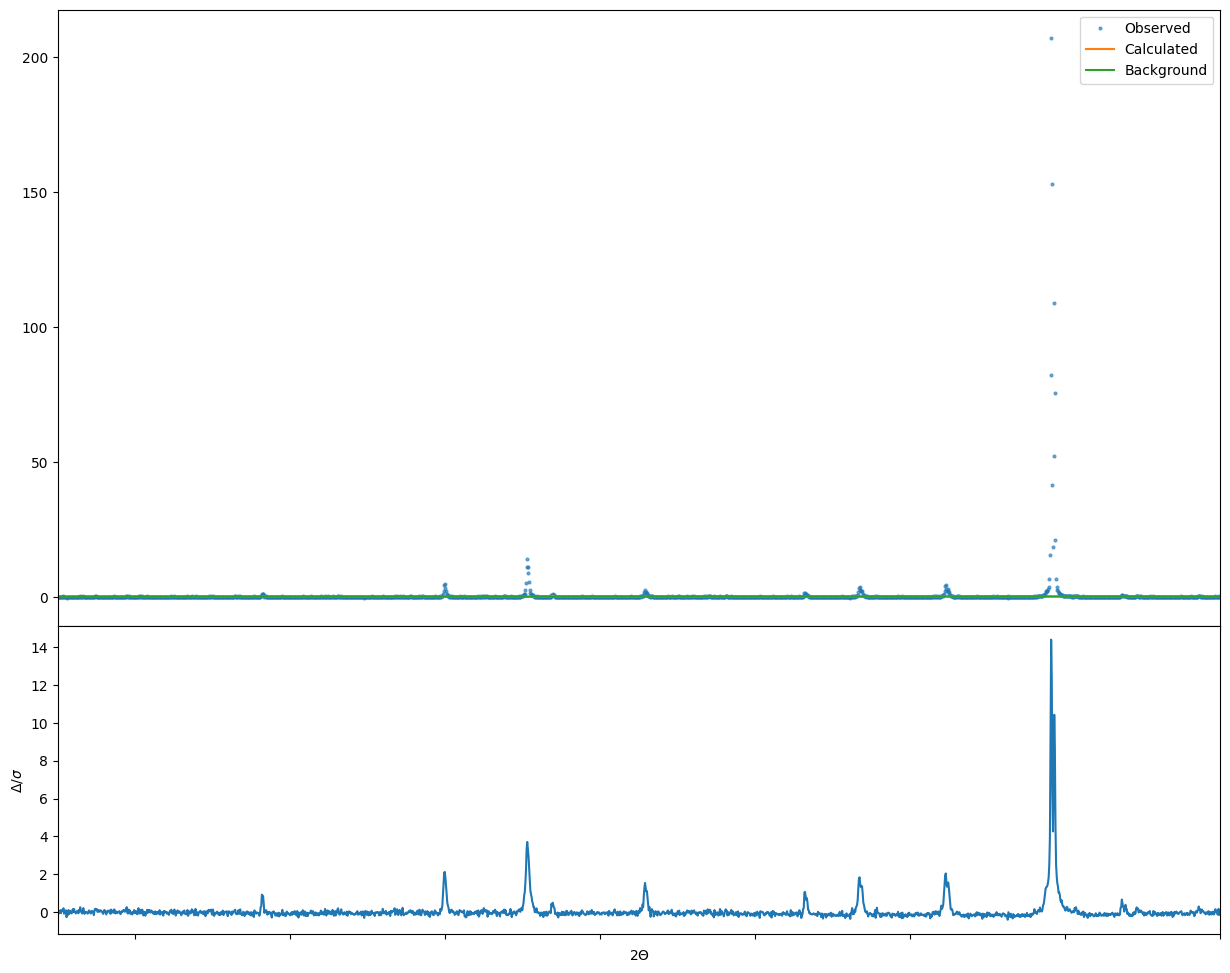

In [26]:
plot_xrd(project, 0)